<a href="https://colab.research.google.com/github/kiransree2002/house_price/blob/main/house_pricing__for_app_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
data = {
    "Area": [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3500,
             1100, 1400, 1700, 2100, 2600],
    "Bedrooms": [2, 2, 3, 3, 4, 4, 4, 5, 5, 5,
                 2, 3, 3, 4, 5],
    "Age": [10, 8, 5, 7, 4, 3, 6, 2, 1, 3,
            12, 6, 8, 5, 2],
    "Price": [25, 30, 40, 48, 55, 60, 68, 75, 85, 95,
              27, 38, 45, 58, 72]
}

df = pd.DataFrame(data)

df.head()

,Area,Bedrooms,Age,Price
0,1000,2,10,25
1,1200,2,8,30
2,1500,3,5,40
3,1800,3,7,48
4,2000,4,4,55


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(15, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      15 non-null     int64
 1   Bedrooms  15 non-null     int64
 2   Age       15 non-null     int64
 3   Price     15 non-null     int64
dtypes: int64(4)
memory usage: 612.0 bytes
None
Area        0
Bedrooms    0
Age         0
Price       0
dtype: int64


In [4]:
X = df[["Area", "Bedrooms", "Age"]]
y = df["Price"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12
Testing samples: 3


In [6]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [7]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [8]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred)

Predictions: [77.52 40.99 30.78]


In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 8.750000000000002
MSE : 115.96630000000006
RMSE: 10.768765017401023
R² Score: 0.8745255229622505


In [10]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

result

,Actual Price,Predicted Price
0,95,77.52
1,38,40.99
2,25,30.78


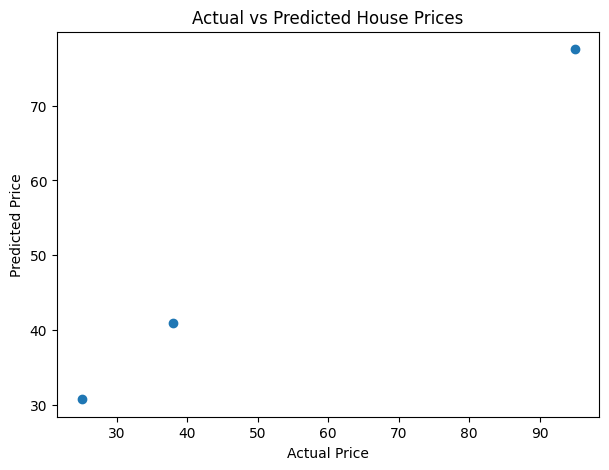

In [11]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [12]:
joblib.dump(model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [13]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#desktopfolder - model.pkl paste & rightclick and new -textdocument open and rename as app.py(remove .text if presented) and
#same app.py open in notepad and type code and control s
#then open vscode open our folder and open app.py
#newterminal - streamlit run app.py
url open akum and app ready ayi



#for app building code
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("model.pkl")

st.title("House Price Prediction")

area = st.number_input("Area", min_value=0)
bedrooms = st.number_input("Bedrooms", min_value=0, step=1)
age = st.number_input("Age", min_value=0, step=1)

if st.button("Predict"):
    input_data = pd.DataFrame(
        [[area, bedrooms, age]],
        columns=["Area", "Bedrooms", "Age"]
    )

    prediction = model.predict(input_data)[0]

    st.success(f"Predicted Price: {prediction:.2f}")